In [1]:
# prerequisites
%pip install -q "qiskit[visualization]~=2.5.1" "qiskit-aer~=0.17"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# From CYBR9027_Lecture_2_Lab_1.ipynb
# Now we load (import) the specific tools we need from the libraries we just installed.
# Think of this like opening the right drawer from a filing cabinet.

# importlib.metadata lets us check which version of a package is installed
from importlib.metadata import version

# matplotlib is the standard Python charting library — we use it for histograms
import matplotlib.pyplot as plt

# numpy is the standard Python maths library — we use it for square roots and rounding
import numpy as np

# pandas lets us display results as neat tables
import pandas as pd

# IPython.display.display() lets us show multiple charts in one cell
from IPython.display import display

# QuantumCircuit is the main building block — it lets us describe a quantum program
from qiskit import QuantumCircuit

# Statevector lets us inspect the exact mathematical state BEFORE measurement
# (this is the "cheat mode" that only works on a simulator, not real hardware)
from qiskit.quantum_info import Statevector

# This tool prepares (transpiles) our circuit for the simulator
from qiskit.transpiler import generate_preset_pass_manager

# These are visualisation helpers:
#   plot_bloch_multivector — draws the Bloch sphere showing the qubit's current state
#   plot_histogram         — draws a bar chart of measurement outcomes
from qiskit.visualization import plot_bloch_multivector, plot_histogram

# AerSimulator is the simulated quantum computer we will use in this lab
from qiskit_aer import AerSimulator

# SamplerV2 is the tool that runs our circuit many times and collects results
from qiskit_aer.primitives import SamplerV2 as AerSampler

# SEED is a fixed starting number for the random number generator.
# Using the same seed means everyone in the class gets the same results.
SEED = 2026

# Print the installed versions so we can check everything loaded correctly
print("Qiskit version:    ", version("qiskit"))
print("Qiskit Aer version:", version("qiskit-aer"))
print("Random seed:       ", SEED)


Qiskit version:     2.5.2
Qiskit Aer version: 0.17.2
Random seed:        2026


In [3]:
# AerSimulator() creates an ideal quantum computer simulator.
# It lets us execute quantum circuits on our ordinary computer.
#
# We store it in SIMULATOR so that we can reuse it later.
SIMULATOR = AerSimulator()

# Before a quantum circuit can be executed, Qiskit prepares it for the
# particular simulator or quantum computer that will run it.
#
# generate_preset_pass_manager() creates the set of steps Qiskit will use
# to do that preparation.
#
# optimization_level=1 means Qiskit will make some simple improvements
# to the circuit, without doing very aggressive optimisation.

PASS_MANAGER = generate_preset_pass_manager(
    optimization_level=1,
    backend=SIMULATOR,
)

# ─── Helper function: sample_counts ─────────────────────────────────────
#
# This function will eventually RUN a circuit many times and count
# how often we measure 0 and how often we measure 1.
#
# Each complete execution of the circuit is called a "shot".
#
# IMPORTANT:
# The lines below, first PREPARE the circuit.
# The quantum experiment has NOT been run yet.

def sample_counts(circuit, shots=1000, seed=SEED):
    # Step 1: Make a copy of the circuit.
    #
    # We add measurement to the copy rather than changing the
    # original circuit you built.
    measured_circuit = circuit.copy()

    # Step 2: Add a measurement instruction.
    #
    # IMPORTANT: this line does NOT measure the qubit now.
    #
    # It adds an instruction to the circuit saying:
    # "When this circuit is eventually executed, measure every qubit
    #  at the end and save the result as classical data."
    #
    # The actual measurement happens later, during sampler.run(...).

    measured_circuit.measure_all()

    # Step 3: Prepare/compile the circuit for the simulator.
    #
    # PASS_MANAGER.run() is slightly confusing:
    # it does NOT run the quantum experiment.
    #
    # It runs Qiskit's COMPILATION/PREPARATION steps over the
    # circuit and produces a simulator-ready version.
    #
    # measured_circuit:
    #       the circuit we wrote, including measurement instructions
    #
    # executable_circuit:
    #       the same experiment, translated/prepared so that
    #       AerSimulator can execute it

    executable_circuit = PASS_MANAGER.run(measured_circuit)

    # Step 4: ACTUALLY RUN the circuit.
    #
    # Up to this point we have only:
    #   1. built the circuit,
    #   2. added an instruction saying "measure at the end",
    #   3. prepared/compiled the circuit for the simulator.
    #
    # Nothing has actually been executed yet.
    #
    # The next line creates the tool that will execute the circuit.
    sampler = AerSampler(default_shots=shots, seed=seed)

    # THIS is where the quantum circuit is actually executed.
    #
    # sampler.run(...) tells the simulator:
    # "Run this complete circuit from the beginning, 'shots' times."
    #
    # For EACH shot, the simulator:
    #   1. starts the qubit again in |0⟩
    #   2. applies all the gates in the circuit
    #   3. reaches the measurement instruction we added earlier
    #   4. MEASURES the qubit
    #   5. records the classical result: 0 or 1
    #
    # So if shots=1000, the whole circuit is executed 1000 separate times.
    #
    # IMPORTANT:
    # We are NOT measuring the same already-collapsed qubit 1000 times.
    # Each shot starts again from the beginning of the circuit.
    result = sampler.run([executable_circuit], shots=shots).result()[0]

    # Step 5: Extract and return the counts dictionary.
    # A counts dictionary looks like: {'0': 512, '1': 488}
    # This means: 512 shots gave outcome 0, and 488 shots gave outcome 1.

    # At this point all the shots have finished.
    # The measurements have already happened during those executions.
    #
    # We now simply READ the stored classical measurement results
    # and count how many times 0 and 1 occurred.
    return result.data.meas.get_counts()

    # ─── Helper function 2: observed_probability ────────────────────────────────
    #
    # This function converts a counts dictionary into a fraction (probability).
    # For example: if counts = {'0': 300, '1': 700}, then observed_probability(counts, '1') = 0.7
    #
    # Parameters:
    #   counts  — the dictionary returned by sample_counts()
    #   outcome — which outcome we want the probability for (default: '1')

def observed_probability(counts, outcome="1"):
    # counts.get(outcome, 0) looks up the count for 'outcome', returning 0 if it's missing
    # sum(counts.values()) gives the total number of shots
    # Dividing gives the fraction: how often did this outcome appear?
    return counts.get(outcome, 0) / sum(counts.values())

print("Setup complete — simulator and helper functions are ready.")
print("You can now use sample_counts() and observed_probability() in all remaining cells.")


Setup complete — simulator and helper functions are ready.
You can now use sample_counts() and observed_probability() in all remaining cells.


# Grover Algorithm
Definition of the Grover algorithm: Given an oracle Uw, GA proceeds as follows:

 - (1) initiate the qubits in state |000...0>.
 - (2) apply a Hadamard gate on each qubit to obtain |s⟩.
 - (3) apply the oracle operator Uw.
 - (4) apply the diffusion operator Us.
 - (5) repeat steps 3 and 4 each q times.
 - (6) measure the qubits in the computational basis and find |w⟩ with a probability very close to 1.

## Problem Statement #1

Find a three-bit string whose first and last bits are 1; the middle bit can be either value. Solutions are 101 and 111 so the oracle should mark these two states as solutions.

```python
def is_solution(candidate):
    return candidate[0] == "1" and candidate[2] == "1"
```


```
→ compute the predicate into a scratch qubit
→ apply Z to the scratch qubit
→ reverse the predicate computation
→ diffusion
→ measurement
```

### Create the oracle

In [4]:
def build_oracle():
    # 4 qubits where last is temporary workspace (target), initially |0>.
    oracle = QuantumCircuit(4, name="Oracle")

    # Compute: q3 is the tag qubit should becomes 1 when control qubit q0 AND control qubit q2 are 1.
    oracle.ccx(2, 0, 3)

    # Mark: apply a Z gate to change the phase of the state where q3=1 (which is when q0 AND q2 are 1).
    oracle.z(3)

    # Uncompute: return target to 0, preserving the phase mark.
    oracle.ccx(2, 0, 3)

    return oracle

In [5]:
oracle = build_oracle()
print(oracle.draw(output="text"))

                    
q_0: ──■─────────■──
       │         │  
q_1: ──┼─────────┼──
       │         │  
q_2: ──■─────────■──
     ┌─┴─┐┌───┐┌─┴─┐
q_3: ┤ X ├┤ Z ├┤ X ├
     └───┘└───┘└───┘


### Apply the oracle to the initial state |000⟩.
The result is a superposition of all states, with the solutions marked by a negative sign.

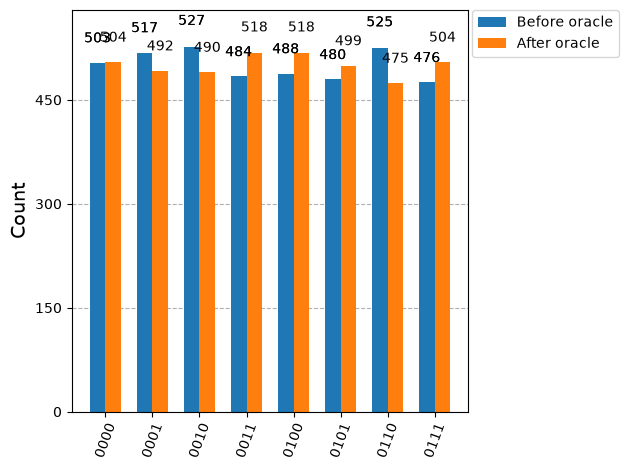

In [6]:
# Three candidate qubits + one state qubit.
before_oracle = QuantumCircuit(4)
before_oracle.h([0, 1, 2])  # state q3 stays at 0.

after_oracle = before_oracle.copy()
after_oracle.compose(build_oracle(), inplace=True)

before_counts = sample_counts(before_oracle, shots=4000)
after_counts = sample_counts(after_oracle, shots=4000)

plot_histogram(
    [before_counts, after_counts],
    legend=["Before oracle", "After oracle"],
)

### Build the diffuser which is implementation of the oracle but 

In [7]:
def build_diffuser():
    ### Diffuser: “Reflect amplitudes about their mean.” → interference
    ### The diffuser is the implementation of the oracle but with a different purpose. It amplifies the probability of the marked state(s) by inverting about the mean amplitude of all states.
    diffuser = QuantumCircuit(3, name="Diffuser")

    diffuser.h([0, 1, 2])
    diffuser.x([0, 1, 2])

    # Phase-flip |111>: H–Toffoli–H implements controlled-controlled-Z.
    diffuser.h(2)
    diffuser.ccx(0, 1, 2)
    diffuser.h(2)

    diffuser.x([0, 1, 2])
    diffuser.h([0, 1, 2])

    return diffuser

In [19]:
grover = after_oracle.copy()
print(grover.draw(output="text"))

     ┌───┐               
q_0: ┤ H ├──■─────────■──
     ├───┤  │         │  
q_1: ┤ H ├──┼─────────┼──
     ├───┤  │         │  
q_2: ┤ H ├──■─────────■──
     └───┘┌─┴─┐┌───┐┌─┴─┐
q_3: ─────┤ X ├┤ Z ├┤ X ├
          └───┘└───┘└───┘


In [20]:
grover.compose(build_diffuser(), qubits=[0, 1, 2], inplace=True)

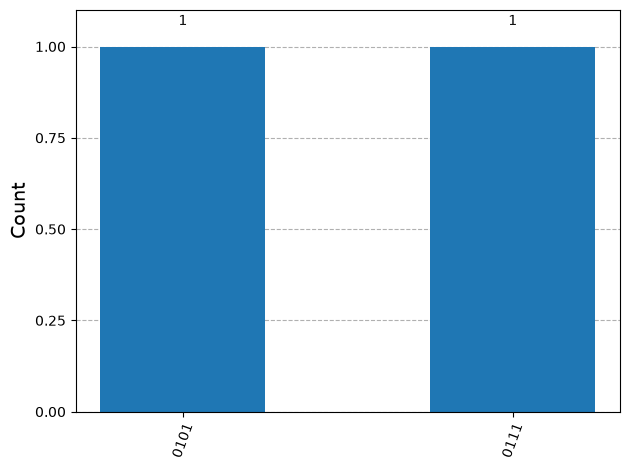

In [22]:
# try with 500 shots.

grover_counts = sample_counts(grover, shots=2)
plot_histogram(grover_counts)

In [23]:
print(grover_counts)

solution_outcomes = {"0101", "0111"}
successes = sum(grover_counts.get(s, 0) for s in solution_outcomes)

print(f"Solutions: {successes}/{sum(grover_counts.values())}")
success_probability = observed_probability(grover_counts, "0101") + observed_probability(grover_counts, "0111")
success_probability


{'0111': 1, '0101': 1}
Solutions: 2/2


1.0

50 shots: 50 solutions (100.0%)
100 shots: 100 solutions (100.0%)
150 shots: 150 solutions (100.0%)
200 shots: 200 solutions (100.0%)
250 shots: 250 solutions (100.0%)
300 shots: 300 solutions (100.0%)
350 shots: 350 solutions (100.0%)
400 shots: 400 solutions (100.0%)
450 shots: 450 solutions (100.0%)
500 shots: 500 solutions (100.0%)


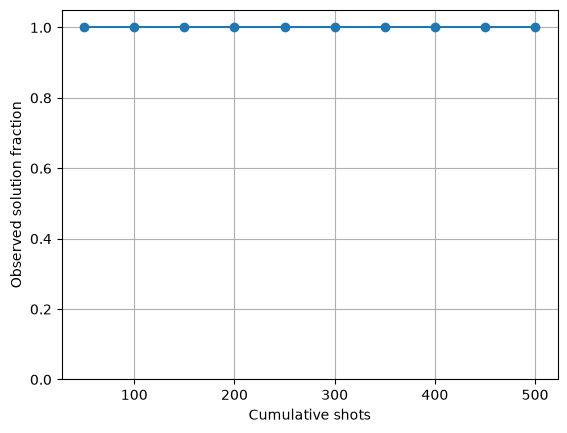

In [24]:
from collections import Counter
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

cumulative_counts = Counter()
totals = []
success_rates = []
snapshots = []

for total_shots in range(50, 501, 50):
    batch = sample_counts(grover, shots=50)
    cumulative_counts.update(batch)

    successes = sum(
        cumulative_counts[s] for s in solution_outcomes
    )
    success_rate = successes / total_shots

    totals.append(total_shots)
    success_rates.append(success_rate)

    if total_shots in (50, 250, 500):
        snapshots.append(dict(cumulative_counts))

    print(
        f"{total_shots} shots: "
        f"{successes} solutions ({success_rate:.1%})"
    )

plot_histogram(
    snapshots,
    legend=["50 shots", "250 shots", "500 shots"],
)

plt.figure()
plt.plot(totals, success_rates, "o-")
plt.xlabel("Cumulative shots")
plt.ylabel("Observed solution fraction")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [ ]:
from collections import Counter

solution_outcomes = {"0101", "0111"}  # Leading 0 is scratch.
cumulative_counts = Counter()
first_solution_batch = None

for total_shots in range(50, 4001, 50):
    cumulative_counts.update(sample_counts(grover, shots=50))

    successes = sum(
        cumulative_counts[outcome]
        for outcome in solution_outcomes
    )

    if successes > 0 and first_solution_batch is None:
        first_solution_batch = total_shots

    print(
        f"Shots: {total_shots:4d} | "
        f"Solutions: {successes:4d} | "
        f"Observed success: {successes / total_shots:.1%}"
    )

print("First batch containing a solution:", first_solution_batch)
print("Final counts:", dict(cumulative_counts))

## Scenario #2